<a href="https://www.kaggle.com/code/shraddhajoshi5/aiesec-predict-high-activity-month?scriptVersionId=340648379" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import requests
import json
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score


In [44]:

ACCESS_TOKEN = "c6p5-wQRwD4Un-CVi6kzilbbUDDkkBtwieqtpFhupIY"   

url = "https://analytics.api.aiesec.org/v2/applications/analyze.json"

rows = []

months = pd.date_range("2022-01-01", "2025-12-01", freq="MS")

for month in months:

    start = month.strftime("%Y-%m-%d")
    end = (month + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")

    params = {
        "access_token": ACCESS_TOKEN,
        "start_date": start,
        "end_date": end,
        "performance_v3[office_id]": 1585
    }

    r = requests.get(url, params=params)

    if r.status_code != 200:
        print(start, r.text)
        continue

    data = r.json()["response"]

    rows.append({
        "month": start[:7],
        "o_matched": data["o_matched_7"]["doc_count"],
        "o_realized": data["o_realized_7"]["doc_count"],
        "i_matched": data["i_matched_7"]["doc_count"],
        "i_realized": data["i_realized_7"]["doc_count"]
    })

df = pd.DataFrame(rows)



In [45]:
df.head()

,month,o_matched,o_realized,i_matched,i_realized
0,2022-01,61,9,26,0
1,2022-02,37,1,44,2
2,2022-03,92,2,125,0
3,2022-04,62,5,133,0
4,2022-05,50,6,115,4


In [50]:
df.to_csv("mc_india_monthly_data_2022_2025.csv")

print("CSV saved successfully!")

CSV saved successfully!


In [48]:
import os

print(os.path.exists("/kaggle/working/mc_india_monthly_data_2022_2025.csv"))

True


In [52]:
print(df.shape)

df.info()

df.describe()

(48, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   month       48 non-null     object
 1   o_matched   48 non-null     int64 
 2   o_realized  48 non-null     int64 
 3   i_matched   48 non-null     int64 
 4   i_realized  48 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.0+ KB


,o_matched,o_realized,i_matched,i_realized
count,48.000000,48.000000,48.000000,48.000000
mean,59.812500,14.375000,103.979167,21.062500
std,26.166941,16.260676,40.457222,25.555452
min,13.000000,0.000000,26.000000,0.000000
25%,40.000000,4.000000,75.000000,5.000000
50%,52.500000,6.500000,98.000000,11.500000
75%,78.250000,17.500000,133.750000,25.000000
max,141.000000,71.000000,215.000000,112.000000


In [66]:
df["month"] = pd.to_datetime(df["month"])

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   month       48 non-null     datetime64[ns]
 1   o_matched   48 non-null     int64         
 2   o_realized  48 non-null     int64         
 3   i_matched   48 non-null     int64         
 4   i_realized  48 non-null     int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 2.0 KB


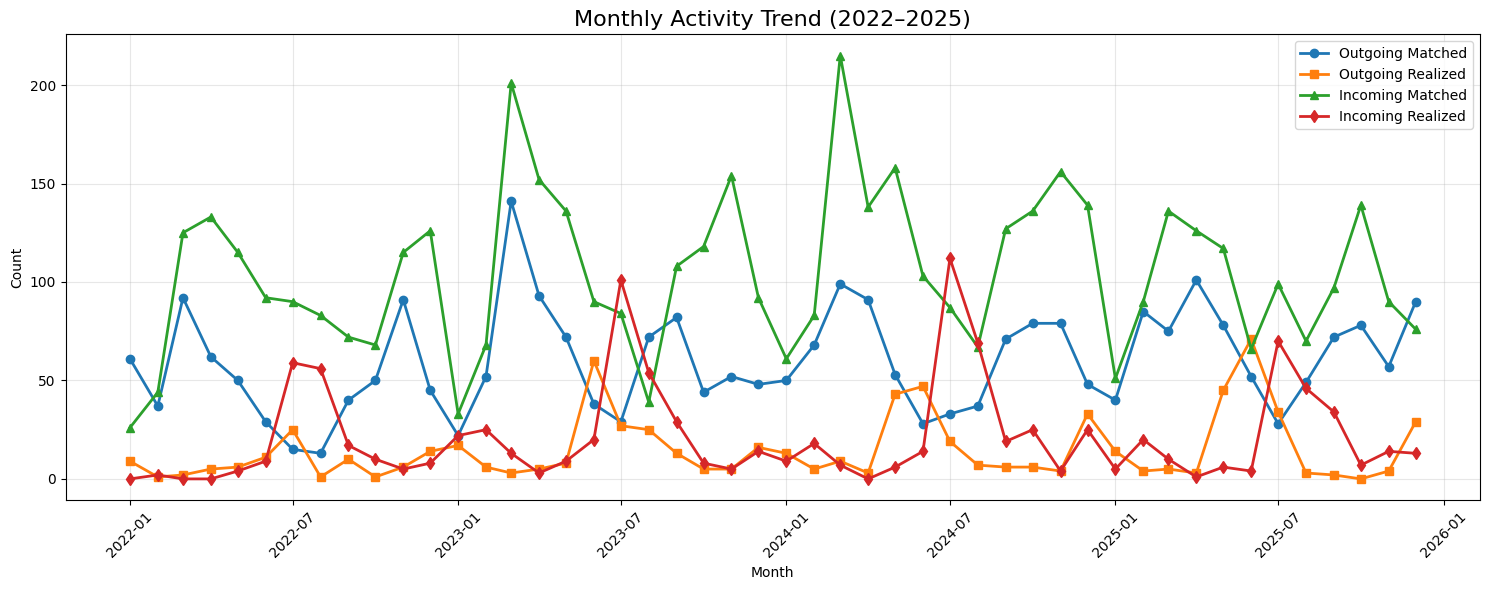

In [73]:
#Time series plot
plt.figure(figsize=(15,6))

plt.plot(df['month'], df['o_matched'],
         marker='o', linewidth=2, label='Outgoing Matched')

plt.plot(df['month'], df['o_realized'],
         marker='s', linewidth=2, label='Outgoing Realized')

plt.plot(df['month'], df['i_matched'],
         marker='^', linewidth=2, label='Incoming Matched')

plt.plot(df['month'], df['i_realized'],
         marker='d', linewidth=2, label='Incoming Realized')

plt.title('Monthly Activity Trend (2022–2025)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

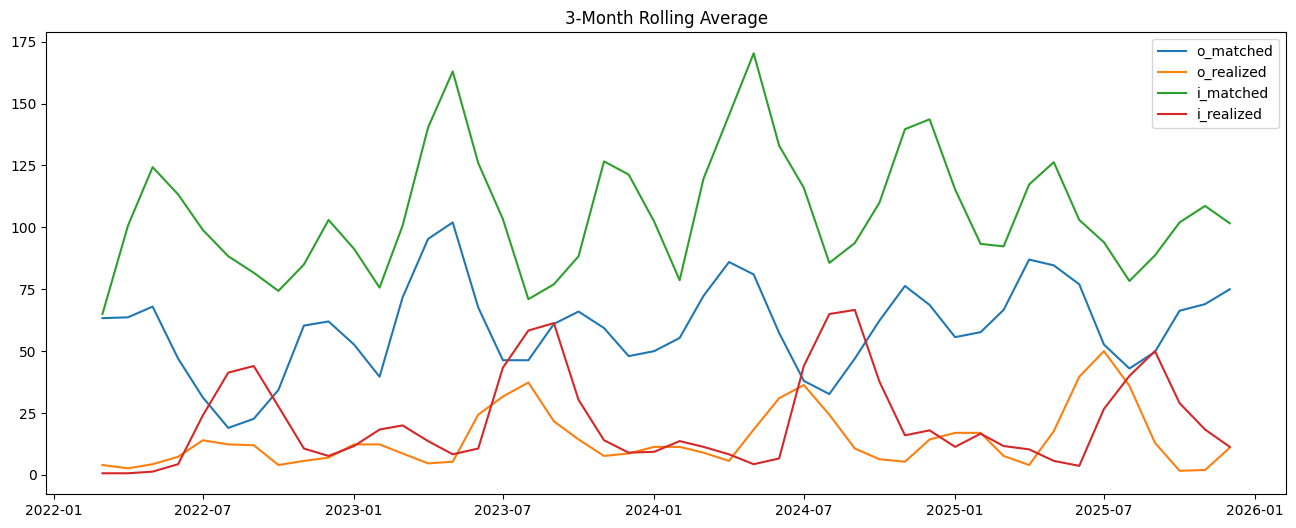

In [74]:
#rolling average
rolling = df.copy()

for col in df.columns[1:]:
    rolling[col] = rolling[col].rolling(3).mean()

plt.figure(figsize=(16,6))

for col in rolling.columns[1:]:
    plt.plot(rolling["month"], rolling[col], label=col)

plt.legend()
plt.title("3-Month Rolling Average")
plt.show()

/tmp/ipykernel_58/3123602245.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly = temp.groupby("Month_Name").mean(numeric_only=True)


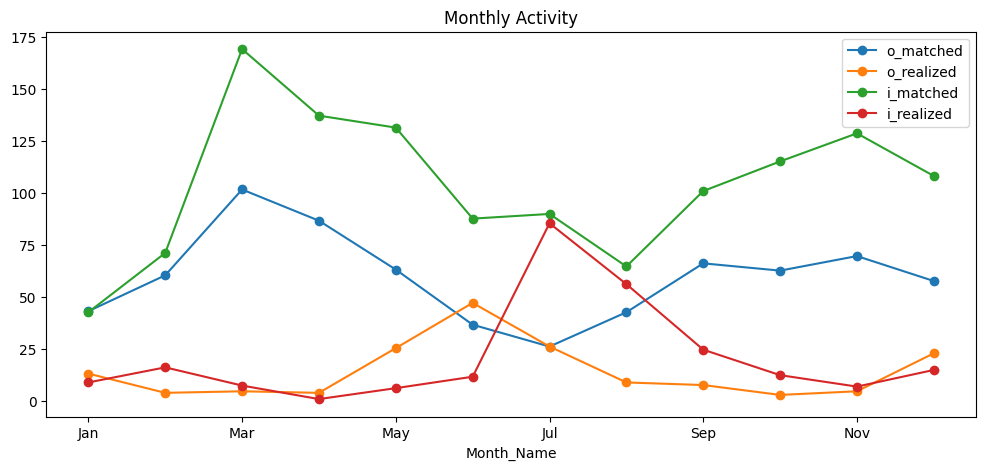

In [84]:
#monthly seasonaliy
temp = df.copy()

temp["Month_Name"] = temp["month"].dt.strftime("%b")

order = ['Jan','Feb','Mar','Apr','May','Jun',
         'Jul','Aug','Sep','Oct','Nov','Dec']

temp["Month_Name"] = pd.Categorical(
    temp["Month_Name"],
    categories=order,
    ordered=True
)

monthly = temp.groupby("Month_Name").mean(numeric_only=True)

monthly.plot(figsize=(12,5), marker='o')
plt.title("Monthly Activity")
plt.show()

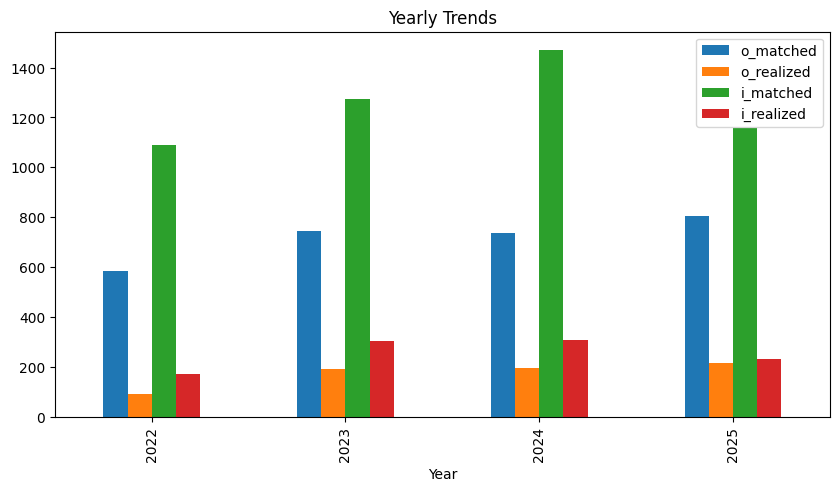

In [87]:
temp["Year"] = temp["month"].dt.year

yearly = temp.groupby("Year").sum(numeric_only=True)

yearly.plot(kind="bar", figsize=(10,5))
plt.title("Yearly Trends")
plt.show()

In [116]:
data = df.copy()


In [146]:
data["time_idx"] = np.arange(len(data))
data["month_num"] = data["month"].dt.month
data["quarter"] = data["month"].dt.quarter

# Cyclic encoding
data["sin_month"] = np.sin(2*np.pi*data["month_num"]/12)
data["cos_month"] = np.cos(2*np.pi*data["month_num"]/12)

feature_cols = [
    "time_idx",
    "month_num",
    "quarter",
    "sin_month",
    "cos_month"
]

targets = [
    "o_matched",
    "o_realized",
    "i_matched",
    "i_realized"
]

In [147]:
data.head()

,month,o_matched,o_realized,i_matched,i_realized,time_idx,month_num,quarter,sin_month,cos_month
0,2022-01-01,61,9,26,0,0,1,1,0.500000,8.660254e-01
1,2022-02-01,37,1,44,2,1,2,1,0.866025,5.000000e-01
2,2022-03-01,92,2,125,0,2,3,1,1.000000,6.123234e-17
3,2022-04-01,62,5,133,0,3,4,2,0.866025,-5.000000e-01
4,2022-05-01,50,6,115,4,4,5,2,0.500000,-8.660254e-01


In [148]:
X = data[feature_cols]
y = data[targets]

In [152]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [153]:
future = pd.DataFrame({
    "month": pd.date_range(
        start="2026-01-01",
        periods=12,
        freq="MS"
    )
})
future["time_idx"] = np.arange(len(data), len(data)+12)
future["month_num"] = future["month"].dt.month
future["quarter"] = future["month"].dt.quarter

future["sin_month"] = np.sin(
    2*np.pi*future["month_num"]/12
)

future["cos_month"] = np.cos(
    2*np.pi*future["month_num"]/12
)

In [154]:
future

,month,time_idx,month_num,quarter,sin_month,cos_month
0,2026-01-01,48,1,1,5.000000e-01,8.660254e-01
1,2026-02-01,49,2,1,8.660254e-01,5.000000e-01
2,2026-03-01,50,3,1,1.000000e+00,6.123234e-17
3,2026-04-01,51,4,2,8.660254e-01,-5.000000e-01
4,2026-05-01,52,5,2,5.000000e-01,-8.660254e-01
5,2026-06-01,53,6,2,1.224647e-16,-1.000000e+00
6,2026-07-01,54,7,3,-5.000000e-01,-8.660254e-01
7,2026-08-01,55,8,3,-8.660254e-01,-5.000000e-01
8,2026-09-01,56,9,3,-1.000000e+00,-1.836970e-16
9,2026-10-01,57,10,4,-8.660254e-01,5.000000e-01


In [156]:
pred = model.predict(future[feature_cols])




In [159]:
future[targets] = np.round(np.clip(pred, 0, None)).astype(int)

In [160]:
future

,month,time_idx,month_num,quarter,sin_month,cos_month,o_matched,o_realized,i_matched,i_realized
0,2026-01-01,48,1,1,5.000000e-01,8.660254e-01,74,8,73,15
1,2026-02-01,49,2,1,8.660254e-01,5.000000e-01,83,16,103,7
2,2026-03-01,50,3,1,1.000000e+00,6.123234e-17,88,24,124,6
3,2026-04-01,51,4,2,8.660254e-01,-5.000000e-01,82,25,137,17
4,2026-05-01,52,5,2,5.000000e-01,-8.660254e-01,77,31,134,26
5,2026-06-01,53,6,2,1.224647e-16,-1.000000e+00,70,34,120,34
6,2026-07-01,54,7,3,-5.000000e-01,-8.660254e-01,59,28,108,47
7,2026-08-01,55,8,3,-8.660254e-01,-5.000000e-01,57,26,94,47
8,2026-09-01,56,9,3,-1.000000e+00,-1.836970e-16,60,24,88,40
9,2026-10-01,57,10,4,-8.660254e-01,5.000000e-01,64,16,100,35


In [161]:
future["activity_score"] = future[targets].sum(axis=1)

threshold = future["activity_score"].quantile(0.75)

future["high_activity"] = future["activity_score"] >= threshold

In [163]:
future.drop(columns=feature_cols, inplace=True)

In [165]:
future.to_csv("predicted_2026.csv", index=False)

